In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# 1. Imports and Config

from dataclasses import dataclass
from pathlib import Path
from typing import Sequence, Tuple, List, Dict

import os
import random
import json

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss
)

import joblib


@dataclass
class Config:
    """
    Global configuration for the experiment / project.
    """
    data_root: Path = Path("/content/drive/MyDrive/data/brisc2025/classification_task")

    out_dir: Path = Path("outputs")
    img_size: int = 128

    class_names: Tuple[str, ...] = ("glioma", "meningioma", "no_tumor", "pituitary")

    search_cv: int = 5
    n_jobs: int = -1
    pca_var: float = 0.95
    random_state: int = 42


CFG = Config()

os.environ["PYTHONHASHSEED"] = str(CFG.random_state)
random.seed(CFG.random_state)
np.random.seed(CFG.random_state)

REPORTS_DIR = CFG.out_dir / "reports"
MODELS_DIR = CFG.out_dir / "models"
for d in (CFG.out_dir, REPORTS_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Configuration settings sucessfully!")

print("\nOutputs will be saved to:", CFG.out_dir.resolve())


Configuration settings sucessfully!

Outputs will be saved to: /content/outputs


In [11]:
# 2. Data loading & preprocessing helpers

def resize_letterbox(img: np.ndarray, target: int) -> np.ndarray:
    """
    Resize image to (target, target) using letterbox (keep aspect ratio, pad with black).
    """
    h, w = img.shape[:2]
    if h == target and w == target:
        return img

    scale = target / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)

    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    pad_top = (target - new_h) // 2
    pad_bottom = target - new_h - pad_top
    pad_left = (target - new_w) // 2
    pad_right = target - new_w - pad_left

    img_padded = cv2.copyMakeBorder(
        img_resized,
        pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=0,
    )
    return img_padded


def list_images_split(root: Path, split: str, class_names: Sequence[str]) -> Tuple[List[Path], np.ndarray]:
    """
    List all images and labels for a given split ('train' or 'test').

    Assumes folder structure: root/split/class_name/*.jpg (or *.png).
    """
    split_dir = root / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Split directory not found: {split_dir}")

    class_to_idx: Dict[str, int] = {name: idx for idx, name in enumerate(class_names)}

    paths: List[Path] = []
    labels: List[int] = []

    for cls_name, idx in class_to_idx.items():
        cls_dir = split_dir / cls_name
        if not cls_dir.exists():
            raise FileNotFoundError(f"Class directory not found: {cls_dir}")

        exts = ("*.jpg", "*.jpeg", "*.png")
        cls_paths: List[Path] = []
        for ext in exts:
            cls_paths.extend(sorted(cls_dir.glob(ext)))

        if not cls_paths:
            raise RuntimeError(f"No images found in {cls_dir} for class '{cls_name}'")

        paths.extend(cls_paths)
        labels.extend([idx] * len(cls_paths))

    if not paths:
        raise RuntimeError(f"No images found in split '{split}' at {split_dir}")

    return paths, np.array(labels, dtype=np.int64)


def load_image_gray(path: Path, img_size: int) -> np.ndarray:
    """
    Load a single image as grayscale, resize with letterbox, normalize to [0,1].
    Returns array of shape (img_size, img_size), dtype float32.
    """
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise IOError(f"Could not read image: {path}")

    img = resize_letterbox(img, img_size)
    img = img.astype(np.float32) / 255.0
    return img


def load_batch(paths: Sequence[Path], img_size: int) -> np.ndarray:
    """
    Load a batch of images into array of shape (N, H, W).
    """
    return np.stack([load_image_gray(p, img_size) for p in paths], axis=0)


def load_data(cfg: Config) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load train/test data according to config.
    """
    print("Listing train/test files...")
    paths_train, y_train = list_images_split(cfg.data_root, "train", cfg.class_names)
    paths_test,  y_test  = list_images_split(cfg.data_root, "test",  cfg.class_names)

    print("Loading image data into memory...")
    X_train = load_batch(paths_train, cfg.img_size)
    X_test  = load_batch(paths_test, cfg.img_size)

    print("Data loaded.")
    print("  Train X:", X_train.shape, " | y:", y_train.shape)
    print("  Test  X:", X_test.shape,  " | y:", y_test.shape)

    return X_train, X_test, y_train, y_test


In [12]:
# 3. Data description

def describe_data(y_train: np.ndarray, y_test: np.ndarray, cfg: Config) -> None:
    """
    Plot class distribution for train and test sets.
    """
    train_counts = pd.Series(y_train).value_counts().sort_index()
    test_counts  = pd.Series(y_test).value_counts().sort_index()

    idx2cls = {i: n for i, n in enumerate(cfg.class_names)}

    train_counts.index = [idx2cls[i] for i in train_counts.index]
    test_counts.index  = [idx2cls[i] for i in test_counts.index]

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    train_counts.plot(kind="bar", ax=ax[0], title="Train class counts")
    test_counts.plot(kind="bar", ax=ax[1], title="Test class counts")

    plt.tight_layout()
    plt.show()


In [13]:
# 4. Feature extractor & model pipeline

HOG_PARAMS_DEFAULT = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
)


class HOGTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-compatible transformer that converts images (N, H, W)
    into HOG feature vectors (N, D).
    """

    def __init__(
        self,
        orientations: int = 9,
        pixels_per_cell: Tuple[int, int] = (8, 8),
        cells_per_block: Tuple[int, int] = (2, 2),
        block_norm: str = "L2-Hys",
    ) -> None:
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.block_norm = block_norm

    def fit(self, X: np.ndarray, y=None):
        # Nothing to fit; purely deterministic transform
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float32)

        # Compute HOG for first sample to determine feature length
        f0 = hog(
            X[0],
            orientations=self.orientations,
            pixels_per_cell=self.pixels_per_cell,
            cells_per_block=self.cells_per_block,
            block_norm=self.block_norm,
            feature_vector=True,
        ).astype(np.float32)

        feats = np.empty((len(X), f0.size), dtype=np.float32)
        feats[0] = f0

        for i in range(1, len(X)):
            feats[i] = hog(
                X[i],
                orientations=self.orientations,
                pixels_per_cell=self.pixels_per_cell,
                cells_per_block=self.cells_per_block,
                block_norm=self.block_norm,
                feature_vector=True,
            ).astype(np.float32)

        return feats


class ShapeLogger(BaseEstimator, TransformerMixin):
    """
    Debugging transformer that prints the shape of intermediate outputs.
    Can be removed or turned off once the pipeline is stable.
    """

    def __init__(self, name: str = "") -> None:
        self.name = name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        print(f"[LOG] {self.name} shape: {getattr(X, 'shape', None)}")
        return X


def build_pipeline(cfg: Config,
                   hog_params: dict | None = None,
                   pca_n_components: int | float | None = None,
                   rf_params: dict | None = None) -> Pipeline:
    """
    Build HOG -> StandardScaler -> PCA -> RandomForest pipeline.

    hog_params, pca_n_components and rf_params can override defaults.
    """
    hog_cfg = {**HOG_PARAMS_DEFAULT, **(hog_params or {})}

    if pca_n_components is not None:
        pca_nc = pca_n_components
    else:
        pca_nc = cfg.pca_var  # could be float (variance ratio) or int (components)

    base_rf_cfg = {
        "random_state": cfg.random_state,
        "n_jobs": cfg.n_jobs,
    }
    rf_cfg = {**base_rf_cfg, **(rf_params or {})}

    pipe = Pipeline(
        [
            ("hog", HOGTransformer(**hog_cfg)),
            ("log1", ShapeLogger("After HOG")),      # optional; remove if too noisy
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=pca_nc, random_state=cfg.random_state)),
            ("log2", ShapeLogger("After PCA")),      # optional
            ("clf", RandomForestClassifier(**rf_cfg)),
        ]
    )
    return pipe


In [14]:
# 5. Hyperparameter search (RandomizedSearchCV)

SPACE_JOINT = {
    # === HOG ===
    "hog__orientations": [9, 12, 18],
    "hog__pixels_per_cell": [(8, 8), (12, 12)],
    "hog__cells_per_block": [(2, 2), (3, 3)],

    # === PCA ===
    "pca__n_components": [0.90, 0.95, 128, 256],

    # === Random Forest ===
    "clf__n_estimators": [200, 400, 600, 800],
    "clf__max_depth": [None, 20, 30, 40],
    "clf__max_features": ["sqrt", "log2"],
    "clf__min_samples_split": [2, 3, 4],
    "clf__min_samples_leaf": [1, 2, 4],
}


def make_cv(cfg: Config) -> StratifiedKFold:
    """
    Create a StratifiedKFold cross-validator.
    """
    return StratifiedKFold(
        n_splits=cfg.search_cv,
        shuffle=True,
        random_state=cfg.random_state,
    )


def hpo(cfg: Config,
        X_train: np.ndarray,
        y_train: np.ndarray,
        param_distributions: dict = SPACE_JOINT) -> dict:
    """
    Run RandomizedSearchCV over the joint search space and return
    a dict containing best_estimator, best_params, best_score, cv_results.
    """
    cv = make_cv(cfg)
    est = build_pipeline(cfg)

    search = RandomizedSearchCV(
        estimator=est,
        param_distributions=param_distributions,
        n_iter=12,
        cv=cv,
        scoring="f1_macro",
        random_state=cfg.random_state,
        n_jobs=cfg.n_jobs,
        verbose=2,
    )

    search.fit(X_train, y_train)

    print("=== Best Params ===")
    print(json.dumps(search.best_params_, indent=2))
    print(f"\nBest CV f1_macro: {search.best_score_:.4f}")

    best_params_path = REPORTS_DIR / "rf_best_params.json"
    with open(best_params_path, "w") as f:
        json.dump(
            {
                "best_params": search.best_params_,
                "best_score": search.best_score_,
            },
            f,
            indent=2,
        )
    print("Saved best params to:", best_params_path.resolve())

    result = {
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "best_score": search.best_score_,
        "cv_results": search.cv_results_,
    }
    return result


In [15]:
# 6. Evaluation utilities (with test loss & overall accuracy)

def evaluate(model: Pipeline,
             X_test: np.ndarray,
             y_test: np.ndarray,
             cfg: Config) -> dict:
    """
    Evaluate a trained model on the test set, print metrics (including loss),
    show confusion matrix, and save metrics+figure.
    """

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        test_loss = float(log_loss(y_test, y_proba))
    else:
        y_proba = None
        test_loss = None

    accuracy = float(accuracy_score(y_test, y_pred))
    metrics = {
        "accuracy": accuracy,
        "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "f1_macro": float(f1_score(y_test, y_pred, average="macro")),
        "test_loss": test_loss,
        "overall_accuracy_pct": accuracy * 100.0,
    }

    print("\n=== Metrics ===")
    for k, v in metrics.items():
        if v is None:
            print(f"{k:>22}: None")
        elif "pct" in k:
            print(f"{k:>22}: {v:.2f}%")
        else:
            print(f"{k:>22}: {v:.4f}")

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=list(cfg.class_names), digits=2))

    if test_loss is not None:
        print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Overall Accuracy: {accuracy * 100.0:.2f}%")

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(cfg.class_names)))
    ax.set_yticks(range(len(cfg.class_names)))
    ax.set_xticklabels(cfg.class_names, rotation=45, ha="right")
    ax.set_yticklabels(cfg.class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
            )

    plt.tight_layout()
    plt.show()

    metrics_path = REPORTS_DIR / "rf_metrics.json"
    fig_path = REPORTS_DIR / "rf_confusion_matrix.png"

    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    fig.savefig(fig_path, dpi=150, bbox_inches="tight")

    print("\nSaved metrics to:", metrics_path.resolve())
    print("Saved confusion matrix figure to:", fig_path.resolve())

    return metrics


=== Loading data ===
Listing train/test files...
Loading image data into memory...
Data loaded.
  Train X: (5000, 128, 128)  | y: (5000,)
  Test  X: (1000, 128, 128)  | y: (1000,)


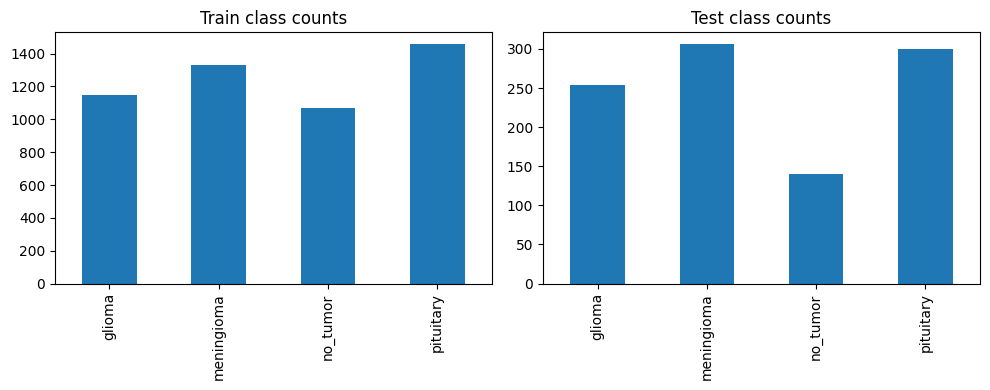


=== Hyperparameter search (Random Forest) ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LOG] After HOG shape: (5000, 10800)
[LOG] After PCA shape: (5000, 128)
=== Best Params ===
{
  "pca__n_components": 128,
  "hog__pixels_per_cell": [
    8,
    8
  ],
  "hog__orientations": 12,
  "hog__cells_per_block": [
    2,
    2
  ],
  "clf__n_estimators": 200,
  "clf__min_samples_split": 4,
  "clf__min_samples_leaf": 2,
  "clf__max_features": "sqrt",
  "clf__max_depth": 20
}

Best CV f1_macro: 0.9146
Saved best params to: /content/outputs/reports/rf_best_params.json

Saved best model to: /content/outputs/models/rf_hog_pca.joblib

=== Evaluation on test set ===
[LOG] After HOG shape: (1000, 10800)
[LOG] After PCA shape: (1000, 128)
[LOG] After HOG shape: (1000, 10800)
[LOG] After PCA shape: (1000, 128)

=== Metrics ===
              accuracy: 0.9120
     balanced_accuracy: 0.9197
              f1_macro: 0.9190
             test_loss: 0.4130
  overall_accuracy_pct: 91.20%



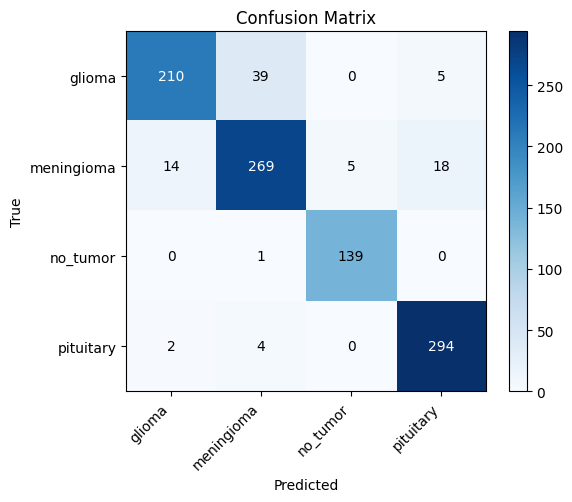


Saved metrics to: /content/outputs/reports/rf_metrics.json
Saved confusion matrix figure to: /content/outputs/reports/rf_confusion_matrix.png

Done.


In [16]:
# 7. Main

def main(cfg: Config):
    # Load data
    print("=== Loading data ===")
    X_train, X_test, y_train, y_test = load_data(cfg)
    describe_data(y_train, y_test, cfg)

    # Hyperparameter search
    print("\n=== Hyperparameter search (Random Forest) ===")
    hpo_result = hpo(cfg, X_train, y_train)
    best_model = hpo_result["best_estimator"]

    # Save model
    model_path = MODELS_DIR / "rf_hog_pca.joblib"
    joblib.dump(best_model, model_path)
    print("\nSaved best model to:", model_path.resolve())

    # Evaluate
    print("\n=== Evaluation on test set ===")
    metrics = evaluate(best_model, X_test, y_test, cfg)

    return {
        "model": best_model,
        "hpo": hpo_result,
        "metrics": metrics,
    }


results = main(CFG)

print("\nDone.")
